In [1]:
import xarray as xr
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

n_embeddings = 32

class ViTBlock(nn.Module):
    def __init__(self, dim, num_heads=6, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(dim, hidden_dim, dropout)
        
    def forward(self, x):
        residual = x
        x = self.norm1(x)
        x = x.transpose(0, 1)
        x, _ = self.attn(x, x, x)
        x = x.transpose(0, 1)
        x = residual + x
        
        residual = x
        x = self.norm2(x)
        x = residual + self.mlp(x)
        return x

class Mlp(nn.Module):
    def __init__(self, dim, hidden_dim, dropout_rate):
        super().__init__()
        self.linear1 = nn.Linear(dim, hidden_dim)
        self.activation = nn.GELU()
        self.drop = nn.Dropout(dropout_rate)
        self.linear2 = nn.Linear(hidden_dim, dim)
        
    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.drop(x)
        x = self.linear2(x)
        x = self.drop(x)
        return x

class WeatherViT(nn.Module):
    def __init__(self, height, width, features, embed_dim=n_embeddings, num_layers=3, num_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.input_dim = height * width * features
        
        # Initial projection
        self.spatial_feature_projection = nn.Sequential(
            nn.Linear(self.input_dim, embed_dim * 2),
            nn.GELU(),
            nn.Linear(embed_dim * 2, embed_dim)
        )
        
        # Encoder layers
        self.encoder_layers = nn.ModuleList([
            ViTBlock(embed_dim, num_heads, mlp_ratio, dropout) 
            for _ in range(num_layers // 2)
        ])
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Linear(embed_dim * 2, embed_dim)
        )
        
        # Decoder layers
        self.decoder_layers = nn.ModuleList([
            ViTBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(num_layers // 2)
        ])
        
        # Output projection
        self.output_proj = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Linear(embed_dim * 2, height * width * features)
        )

        # Normalization layers
        self.input_norm = nn.LayerNorm(embed_dim)
        self.output_norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.pos_embedding = nn.Parameter(torch.randn(1, 5, embed_dim))

    def forward(self, x):
        b, t, h, w, f = x.shape
        
        # Initial embedding
        x_flat = x.reshape(b, t, -1)
        x_emb = self.spatial_feature_projection(x_flat)
        x_emb = x_emb + self.pos_embedding
        x_emb = self.input_norm(x_emb)
        
        # Encoder pathway
        skip_features = []
        for encoder_layer in self.encoder_layers:
            x_emb = encoder_layer(x_emb)
            skip_features.append(x_emb)
        
        # Bottleneck
        x_emb = self.bottleneck(x_emb)
        
        # Decoder pathway with skip connections
        for i, decoder_layer in enumerate(self.decoder_layers):
            skip_connection = skip_features[-(i+1)]
            x_emb = x_emb + skip_connection  # Add skip connection
            x_emb = decoder_layer(x_emb)
        
        # Final processing
        x_emb = self.output_norm(x_emb)
        x_reconstructed = self.output_proj(x_emb[:, -1])
        x_final = x_reconstructed.reshape(b, h, w, f)
        
        return x_final

def create_sequences(data, seq_length=5):
    sequences = []
    targets = []
    for i in range(len(data) - seq_length):
        seq = data[i:i+seq_length] # Shape: [time, h, w, f]
        target = data[i+seq_length]  # Shape: [h, w, f]
        sequences.append(seq)
        targets.append(target)
    return torch.stack(sequences), torch.stack(targets)



In [2]:

# Load and normalize data
ds = xr.open_dataset('ERA5_CPT_2010_2023.nc')
features = torch.tensor(
    np.stack([ds[var].values for var in ds.data_vars], axis=-1),
    dtype=torch.float32
)

# Add normalization
mean = features.mean(dim=0)
std = features.std(dim=0)
features = (features - mean) / std

# Setup device
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Create sequences
sequences, targets = create_sequences(features)
print(f"Data shape: {sequences.shape}")

# Initialize model
_, h, w, f = features.shape
model = WeatherViT(h, w, f).to(device)

# Calculate split index (80% of data)
split_idx = int(0.8 * len(sequences))

# Split sequences and targets
train_sequences = sequences[:split_idx]
train_targets = targets[:split_idx]
val_sequences = sequences[split_idx:]
val_targets = targets[split_idx:]

print(f"Training samples: {len(train_sequences)}")
print(f"Validation samples: {len(val_sequences)}")

# Training setup
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.25, patience=25)

num_epochs = 1000
patience = 100

best_loss = float('inf')
epochs_without_improvement = 0
batch_size = 64

# Training loop
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0
    num_batches = 0
    
    for i in range(0, len(train_sequences), batch_size):
        batch_end = min(i + batch_size, len(train_sequences))
        data = train_sequences[i:batch_end].to(device)
        target = train_targets[i:batch_end].to(device)
        
        output = model(data)
        loss = criterion(output, target)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        num_batches += 1
        
        del output, loss
        if device == 'mps':
            torch.mps.empty_cache()
    
    avg_train_loss = train_loss / num_batches
    
    # Validation phase
    model.eval()
    val_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for i in range(0, len(val_sequences), batch_size):
            batch_end = min(i + batch_size, len(val_sequences))
            data = val_sequences[i:batch_end].to(device)
            target = val_targets[i:batch_end].to(device)
            
            output = model(data)
            loss = criterion(output, target)
            
            val_loss += loss.item()
            num_batches += 1
            
            del output, loss
            if device == 'mps':
                torch.mps.empty_cache()
    
    avg_val_loss = val_loss / num_batches
    
    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
    
    # Update learning rate based on validation loss
    scheduler.step(avg_val_loss)
    
    # Early stopping check using validation loss
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss,
            'mean': mean,
            'std': std
        }, 'weather_vit.pt')
    else:
        epochs_without_improvement += 1
        
    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break


Using device: mps
Data shape: torch.Size([5108, 5, 81, 81, 6])
Training samples: 4086
Validation samples: 1022
Epoch 1/1000:
Train Loss: 1.0079, Val Loss: 0.9898
Epoch 2/1000:
Train Loss: 0.9498, Val Loss: 0.9168
Epoch 3/1000:
Train Loss: 0.8607, Val Loss: 0.8293
Epoch 4/1000:
Train Loss: 0.7748, Val Loss: 0.7568
Epoch 5/1000:
Train Loss: 0.7070, Val Loss: 0.6985
Epoch 6/1000:
Train Loss: 0.6535, Val Loss: 0.6514
Epoch 7/1000:
Train Loss: 0.6085, Val Loss: 0.6112
Epoch 8/1000:
Train Loss: 0.5705, Val Loss: 0.5773
Epoch 9/1000:
Train Loss: 0.5388, Val Loss: 0.5481
Epoch 10/1000:
Train Loss: 0.5112, Val Loss: 0.5243
Epoch 11/1000:
Train Loss: 0.4880, Val Loss: 0.5049
Epoch 12/1000:
Train Loss: 0.4702, Val Loss: 0.4888
Epoch 13/1000:
Train Loss: 0.4540, Val Loss: 0.4737
Epoch 14/1000:
Train Loss: 0.4411, Val Loss: 0.4627
Epoch 15/1000:
Train Loss: 0.4290, Val Loss: 0.4494
Epoch 16/1000:
Train Loss: 0.4177, Val Loss: 0.4395
Epoch 17/1000:
Train Loss: 0.4076, Val Loss: 0.4297
Epoch 18/1000:

Retrieve embeddings for each time step and save to file

In [131]:
embeddings = []
for i in range(len(features)):
    x_flat = features[i].reshape(-1).unsqueeze(0)
    embedding = model.spatial_feature_projection(x_flat.to(device)).to('cpu')
    embeddings.append(embedding.detach().numpy())

Store them in my original xarray dataset

In [132]:
ds_embed = xr.DataArray(np.concat(embeddings), dims=["time", "embedding_dim"])

ds_embed['time'] = ds.time
ds_embed['embedding_dim'] = range(n_embeddings)

ds = xr.merge([ds, ds_embed.to_dataset(name = 'embeddings')])

No we do the exact same as in som.ipynb but instead of operating on our 6*81*81 (var*lat*lon) features we now consider only the 256 embeddings for each time step

In [133]:
from minisom import MiniSom

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

This is the key change, the original commented next to it to highlight that

In [134]:
data = ds.embeddings.values # np.stack([ds[var].values for var in ds.data_vars], axis=1)

data = data.reshape(5113, n_embeddings) #data.reshape(5113, 6*81*81)

Plot the length of the embeddings

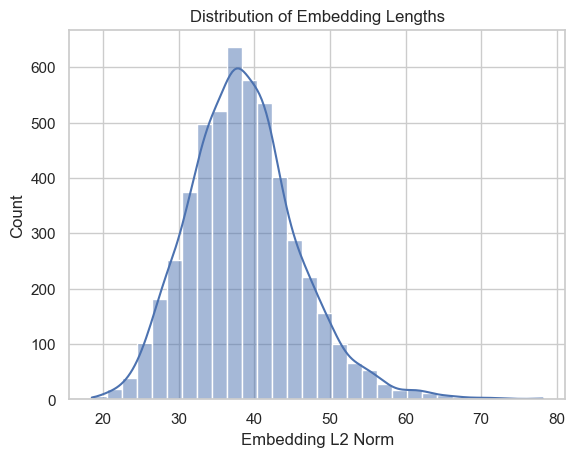

In [135]:
embedding_lengths = np.linalg.norm(data, axis=1)

# Plot distribution of embedding lengths
sns.set(style="whitegrid")
sns.histplot(embedding_lengths, kde=True, bins=30)
plt.xlabel("Embedding L2 Norm")
plt.title("Distribution of Embedding Lengths")
plt.show()

A plot showing the length of vector is not very meaningfull - goes here

In [ ]:
from sklearn.preprocessing import normalize
unit_embeddings = normalize(data, norm='l2')

Now rather than a SOM we will use a t-SNE clustering algorithm, which is a possibility due to the smaller sample size. 

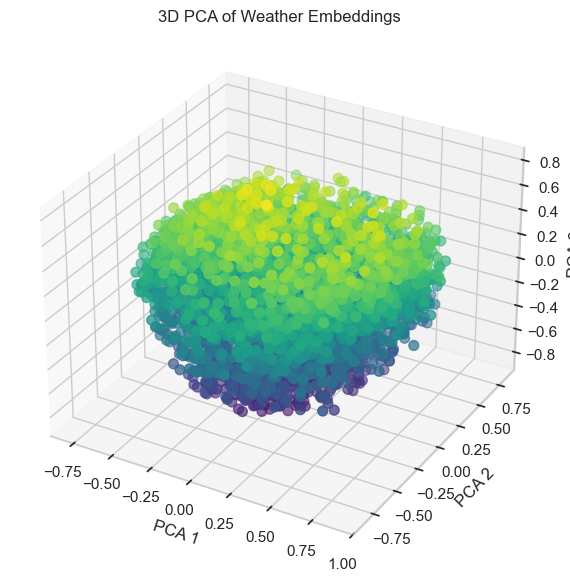

In [159]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D


pca = PCA(n_components=3)
pca_components = pca.fit_transform(unit_embeddings)


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_components[:, 0], pca_components[:, 1], pca_components[:, 2],
           c=pca_components[:, 2], cmap='viridis', s=50)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.title('3D PCA of Weather Embeddings')
plt.show()


In [168]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:        (latitude: 81, longitude: 81, time: 5113, embedding_dim: 32,
                    variable: 6)
Coordinates:
  * latitude       (latitude) float32 324B -24.0 -24.25 -24.5 ... -43.75 -44.0
  * longitude      (longitude) float32 324B 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * time           (time) datetime64[ns] 41kB 2010-01-01T11:30:00 ... 2023-12...
  * embedding_dim  (embedding_dim) int64 256B 0 1 2 3 4 5 ... 26 27 28 29 30 31
    tsne_cluster   (time) int32 20kB 10 14 13 2 14 10 10 10 ... 4 2 2 2 2 13 2
  * variable       (variable) <U6 144B 'uas' 'vas' 'ps' ... 'tasmin' 'tasdp'
Data variables:
    uas            (time, latitude, longitude) float32 134MB -4.664 ... 7.239
    vas            (time, latitude, longitude) float32 134MB 7.722 ... 3.768
    ps             (time, latitude, longitude) float32 134MB 1.016e+05 ... 1....
    tasmax         (time, latitude, longitude) float32 134MB 294.2 ... 284.7
    tasmin         (time, latitude, longitude) float32 134MB 293.5 ... 283.2
    tasdp          (time, latitude, longitude) float32 134MB 289.4 ... 281.8
    embeddings     (time, embedding_dim) float32 654kB -11.22 2.28 ... -0.2565
    rh             (time, latitude, longitude) float32 134MB 74.02 ... 82.87
    predictions    (time, latitude, longitude, variable) float32 805MB nan .....

/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/peter/.local/share/mamba/envs/som_pytorch_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


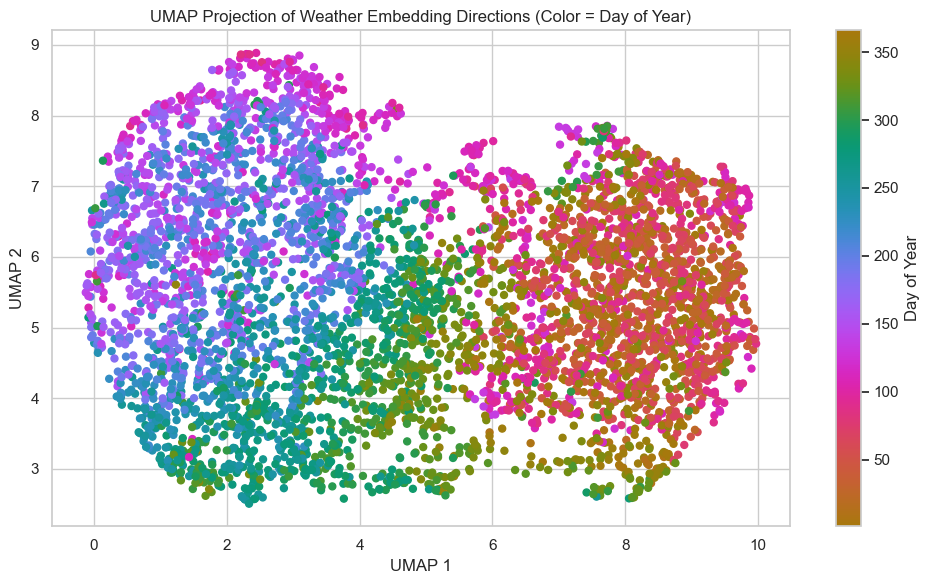

In [175]:
from umap import UMAP
import matplotlib.pyplot as plt
import cmocean

# UMAP projection
umap = UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
proj = umap.fit_transform(unit_embeddings)

# Get day-of-year values for coloring
doy = ds.time.dt.dayofyear.values

# Plot with colorbar and axis labels
plt.figure(figsize=(10, 6))
sc = plt.scatter(proj[:, 0], proj[:, 1], c=doy, cmap=cmocean.cm.phase, s=25)
plt.colorbar(sc, label='Day of Year')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title("UMAP Projection of Weather Embedding Directions (Color = Day of Year)")
plt.tight_layout()
plt.show()


In [141]:
from sklearn.cluster import KMeans

n_clusters = 16  # or use silhouette score to choose
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(unit_embeddings)

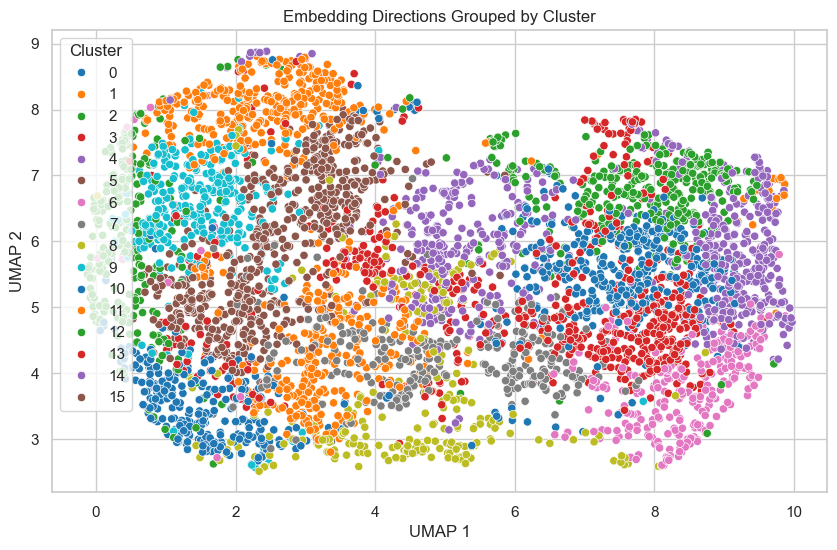

In [176]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=proj[:, 0], y=proj[:, 1], hue=labels, palette='tab10')
plt.title("Embedding Directions Grouped by Cluster")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster")
plt.show()

Add the cluster labels to our xarray dataset

In [182]:
ds = ds.assign_coords(KMeans_cluster=('time', labels))

And plot

In [183]:
import thermofeel
import cmocean.cm as cmo

Relative humidity to visualise, I forgot to add precipitation to the original dataset when I subsetted

In [184]:
ds['rh'] = thermofeel.calculate_relative_humidity_percent(ds.tasmax,ds.tasdp)

In [185]:
ds.to_netcdf('ERA5_CPT_2010_2023_with_embeddings_tsne.nc')

Plot

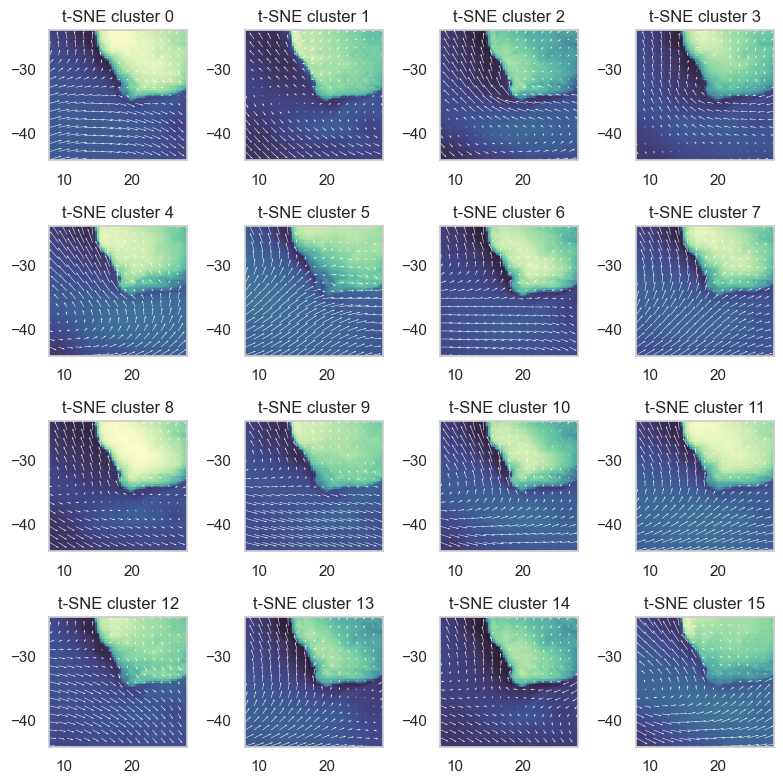

In [186]:
grouped = ds.groupby('KMeans_cluster').mean(dim='time')

# Create the plot
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.flatten()

# Plot each node with pressure as contours and wind as quivers
for i, node in enumerate(sorted(grouped.KMeans_cluster.values)):
    # Plot pressure
    im = grouped.rh.sel(KMeans_cluster=node).plot(ax=axes[i], cmap=cmo.deep, vmin = grouped.rh.min().item(), vmax = grouped.rh.max().item(),
                                           add_colorbar=False)
    
    # Add quiver plot for wind (subsample for clarity)
    step = 5  # Adjust this to control arrow density
    q = axes[i].quiver(grouped.longitude[::step], grouped.latitude[::step],
                      grouped.uas.sel(KMeans_cluster=node)[::step, ::step],
                      grouped.vas.sel(KMeans_cluster=node)[::step, ::step],
                      scale=100, color='white')  # Adjust scale as needed
    
    axes[i].set_title(f't-SNE cluster {node}')
    axes[i].set_ylabel(f'')
    axes[i].set_xlabel(f'')

plt.tight_layout()
plt.show()

So to me this is really cool, just using our embeddings, (which reduced our data from 39366 (6*81*81) to 32 data points), we can accurately recreate our som nodes. The next question is why does this matter? My initial though is identifying which dimension in our embeddings is say seasonality and removing means we could more realistically compare autumn and winter. Which would make a massive difference to increasing sample size when trying to attribute an event.(I think)

Finally lets just check how well our model actually works

Step 1 is to get predictions for all sequences and save this to our dataset

In [149]:
predictions = []
with torch.no_grad():
    for i in range(len(sequences)):
        pred = model.forward(sequences[i].unsqueeze(0).to(device))
        pred_np = pred.cpu().detach().numpy()[0]
        unscaled_pred = pred_np * std.cpu().detach().numpy() + mean.cpu().detach().numpy() # Unscale predictions
        predictions.append(unscaled_pred)

predictions = np.stack(predictions)

ds_pred = xr.DataArray(
    predictions,
    dims=['time', 'latitude', 'longitude', 'variable'],  # Removed pred_step dimension
    coords={
        'time': ds.time[5:],  # Start from index 5 since we need 5 timesteps for first prediction
        'latitude': ds.latitude,
        'longitude': ds.longitude,
        'variable': list(ds.data_vars)[:6]
    }
)
ds = ds.assign(predictions=ds_pred)

In [150]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:        (latitude: 81, longitude: 81, time: 5113, embedding_dim: 32,
                    variable: 6)
Coordinates:
  * latitude       (latitude) float32 324B -24.0 -24.25 -24.5 ... -43.75 -44.0
  * longitude      (longitude) float32 324B 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * time           (time) datetime64[ns] 41kB 2010-01-01T11:30:00 ... 2023-12...
  * embedding_dim  (embedding_dim) int64 256B 0 1 2 3 4 5 ... 26 27 28 29 30 31
    tsne_cluster   (time) int32 20kB 10 14 13 2 14 10 10 10 ... 4 2 2 2 2 13 2
  * variable       (variable) <U6 144B 'uas' 'vas' 'ps' ... 'tasmin' 'tasdp'
Data variables:
    uas            (time, latitude, longitude) float32 134MB -4.664 ... 7.239
    vas            (time, latitude, longitude) float32 134MB 7.722 ... 3.768
    ps             (time, latitude, longitude) float32 134MB 1.016e+05 ... 1....
    tasmax         (time, latitude, longitude) float32 134MB 294.2 ... 284.7
    tasmin         (time, latitude, longitude) float32 134MB 293.5 ... 283.2
    tasdp          (time, latitude, longitude) float32 134MB 289.4 ... 281.8
    embeddings     (time, embedding_dim) float32 654kB -11.22 2.28 ... -0.2565
    rh             (time, latitude, longitude) float32 134MB 74.02 ... 82.87
    predictions    (time, latitude, longitude, variable) float32 805MB nan .....

And a quick plot to see how well it works

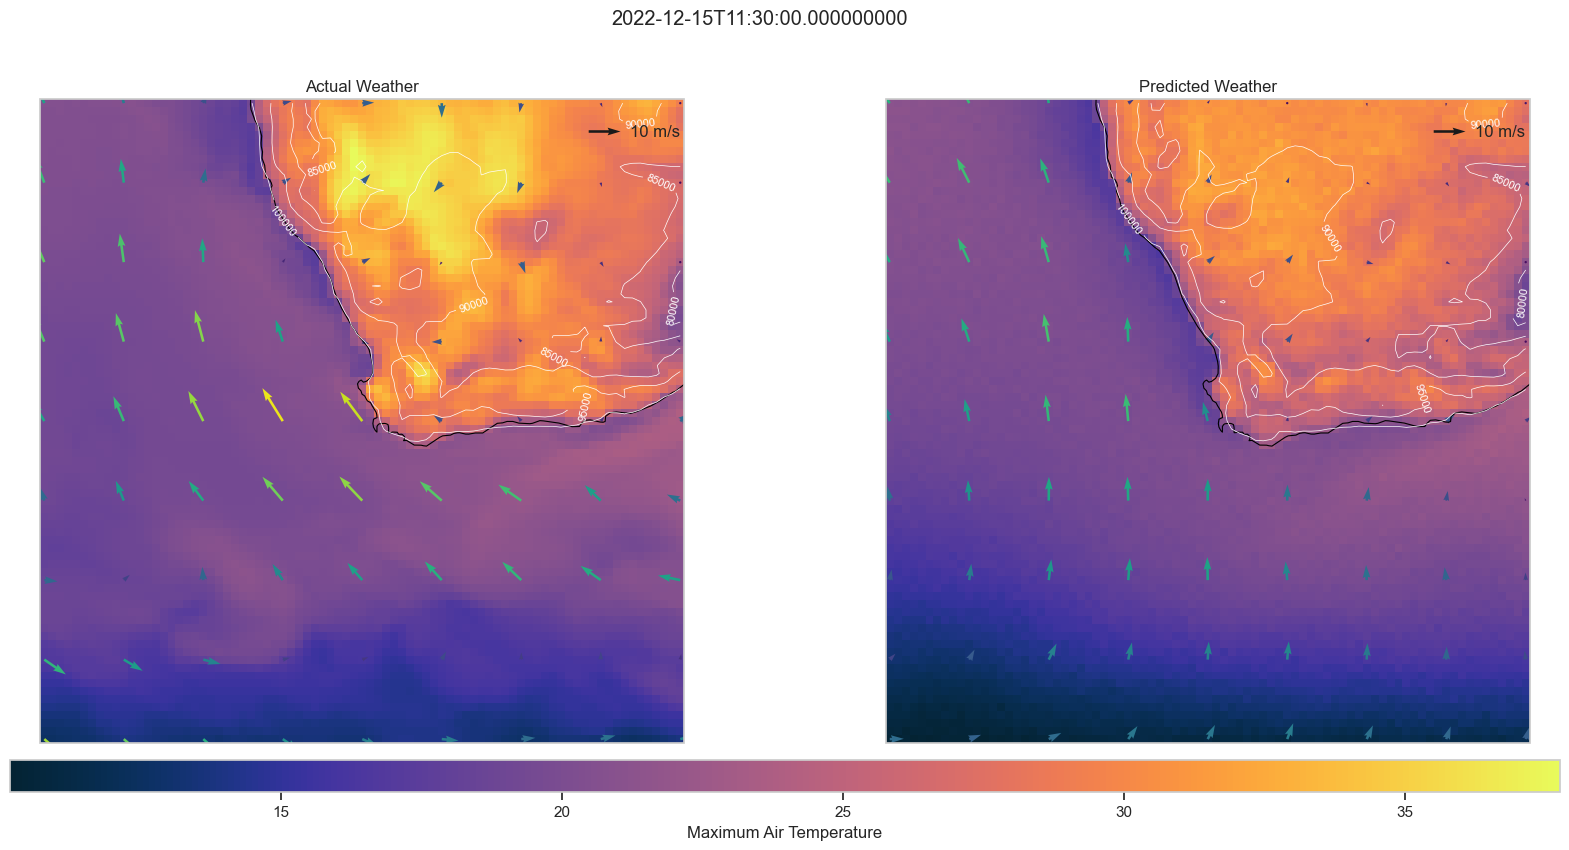

In [151]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean.cm as cmo

dst = ds.sel(time=ds.time.values[np.random.randint(int(len(ds.time)*0.8), len(ds.time))], method = 'nearest') # random day

temp_min = min((dst.tasmax - 273.15).min(), 
               (dst.predictions.sel(variable='tasmax') - 273.15).min())
temp_max = max((dst.tasmax - 273.15).max(), 
               (dst.predictions.sel(variable='tasmax') - 273.15).max())

ps_min = min(dst.ps.min(), dst.predictions.sel(variable='ps').min())
ps_max = max(dst.ps.max(), dst.predictions.sel(variable='ps').max())

ws_actual = np.sqrt(dst.uas**2 + dst.vas**2)
ws_pred = np.sqrt(dst.predictions.sel(variable='uas')**2 + dst.predictions.sel(variable='vas')**2)
ws_min = min(ws_actual.min(), ws_pred.min())
ws_max = max(ws_actual.max(), ws_pred.max())

fig = plt.figure(figsize=(20, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[20, 1], hspace=0.05)


ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())


def plot_weather_map(ax, ds_data, title):
    im = (ds_data.tasmax - 273.15).plot(ax=ax, cmap=cmo.thermal, transform=ccrs.PlateCarree(), add_colorbar=False,
                                        vmin=temp_min, vmax=temp_max)
    cs = ds_data.ps.plot.contour(ax=ax, colors='white', linewidths=0.5, transform=ccrs.PlateCarree(),)
                                 #vmin=ps_min, vmax=ps_max) # hmm hard to fix fine without 
    ax.clabel(cs, inline=True, fontsize=8)
    
    ws = np.sqrt(ds_data.uas**2 + ds_data.vas**2)
    step = 10
    q = ax.quiver(ds_data.longitude[::step], ds_data.latitude[::step],
                  ds_data.uas[::step, ::step],
                  ds_data.vas[::step, ::step],
                  ws[::step, ::step],
                  scale=10,
                  scale_units='xy',
                  width=0.004,
                  cmap='viridis',
                  clim=(ws_min, ws_max))
    
    ax.coastlines('50m', linewidth=0.8)
    ax.set_title(title)
    return im, q


im1, q1 = plot_weather_map(ax1, dst, 'Actual Weather')


pred_data = dst.copy()
for var in ['uas', 'vas', 'ps', 'tasmax']:
    pred_data[var] = dst.predictions.sel(variable=var)
im2, q2 = plot_weather_map(ax2, pred_data, 'Predicted Weather')


cbar_ax = fig.add_subplot(gs[1, :])
plt.colorbar(im1, cax=cbar_ax, orientation='horizontal', label='Maximum Air Temperature')
plt.quiverkey(q1, 0.9, 0.95, 10, '10 m/s', labelpos='E')
plt.quiverkey(q2, 0.9, 0.95, 10, '10 m/s', labelpos='E')
plt.suptitle(dst.time.values)
plt.show()

Hmmm. impressive. Although the model has seen this data before.

Spatial mean:

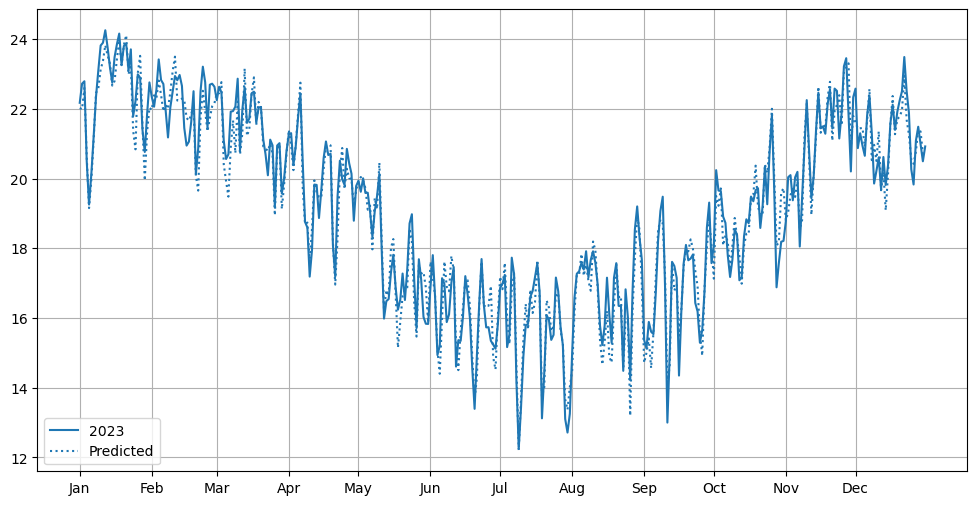

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))

for year in np.unique(ds.time.dt.year.values)[-1:]:
    line = ax.plot(ds.sel(time=str(year)).time.dt.dayofyear, 
                  ds.sel(time=str(year)).tasmax.mean(['latitude', 'longitude']) - 273.15,
                  label=str(year))
    ax.plot(ds.sel(time=str(year)).time.dt.dayofyear,
            ds.predictions.sel(time=str(year), variable='tasmax').mean(['latitude', 'longitude']) - 273.15,
            linestyle=':', color=line[0].get_color(), label = 'Predicted')

ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335], 
              ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid()
plt.show()

CPT:

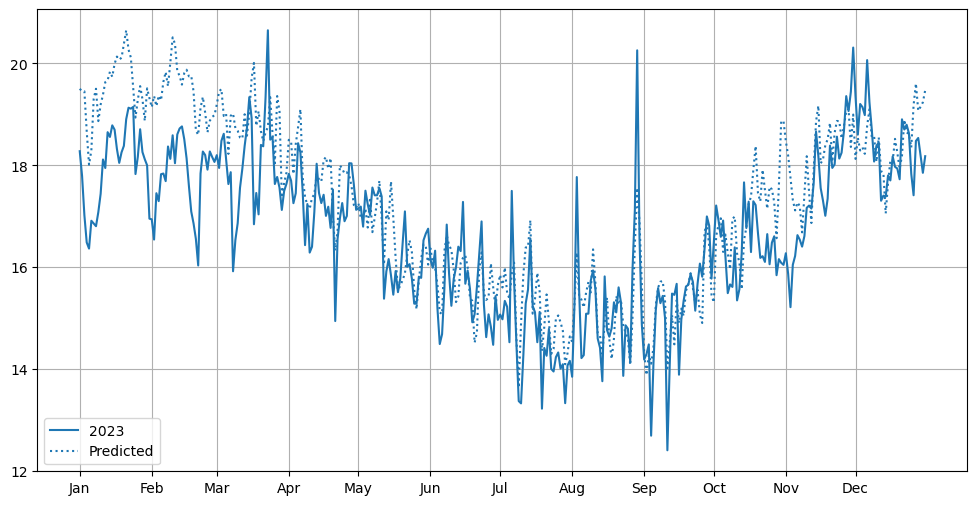

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

for year in np.unique(ds.time.dt.year.values)[-1:]:
    line = ax.plot(ds.sel(time=str(year)).time.dt.dayofyear, 
                  ds.sel(time=str(year)).tasmax.sel(latitude = -34, longitude = 18) - 273.15,
                  label=str(year))
    ax.plot(ds.sel(time=str(year)).time.dt.dayofyear,
            ds.predictions.sel(time=str(year), variable='tasmax').sel(latitude = -34, longitude = 18) - 273.15,
            linestyle=':', color=line[0].get_color(), label = 'Predicted')

ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335], 
              ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid()
plt.show()

In [34]:
ds.tasmax.quantile(0.99).item()

309.76217895507807

In [42]:
hot_ds = ds.where(ds.tasmax > ds.tasmax.quantile(0.99).item()).dropna(dim = 'time', how = 'all')

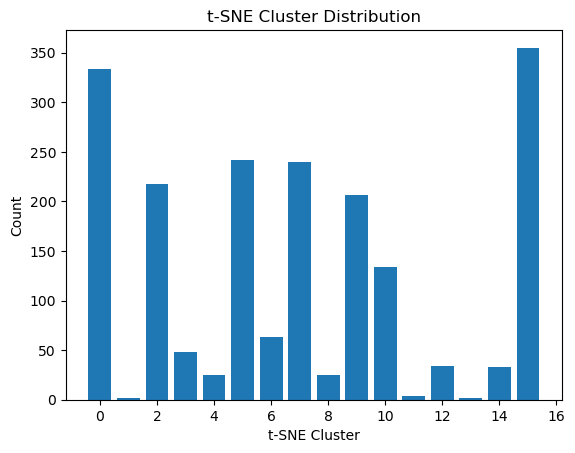

In [48]:
hot_ds_tsne = hot_ds['KMeans_cluster']  # xarray.DataArray
unique, counts = np.unique(hot_ds_tsne.values, return_counts=True)

# Plot manually
plt.bar(unique, counts)
plt.xlabel("t-SNE Cluster")
plt.ylabel("Count")
plt.title("t-SNE Cluster Distribution")
plt.show()


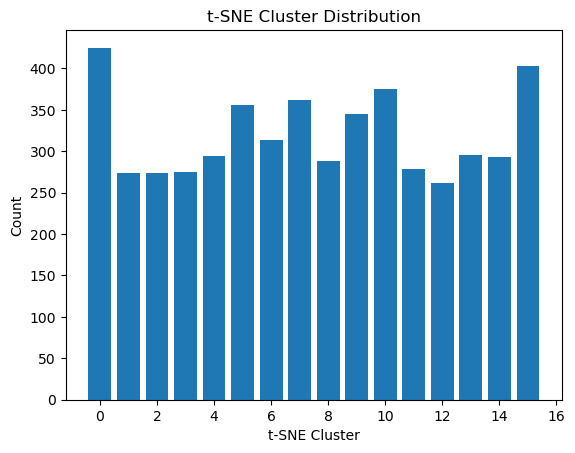

In [50]:
hot_ds_tsne = ds['KMeans_cluster']  # xarray.DataArray
unique, counts = np.unique(hot_ds_tsne.values, return_counts=True)

# Plot manually
plt.bar(unique, counts)
plt.xlabel("t-SNE Cluster")
plt.ylabel("Count")
plt.title("t-SNE Cluster Distribution")
plt.show()
